Going to use the -short files now to hopefully get a slice and plot intensity. Want to pick the clearest one.

Edit: will stick to the regular files for a bit longer.

In [3]:
import sunpy.map
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np

files = sorted(glob.glob('../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T16*.fits'))

maps = [sunpy.map.Map(f) for f in files]
map_times = pd.to_datetime([m.date.iso for m in maps])

target = pd.Timestamp("2026-08-20 16:29:46")
closest_idx = np.abs(map_times - target).argmin()

m = maps[closest_idx]
print(m.date.iso)

2026-08-20 16:29:56.285


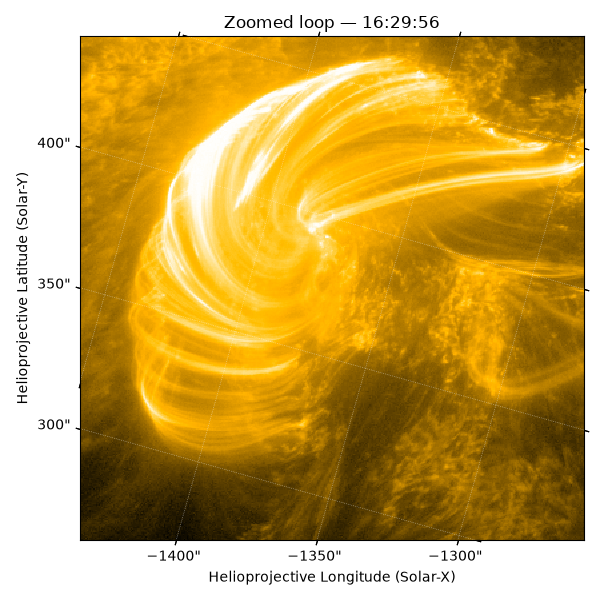

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

zoom_width = 150 * u.arcsec
zoom_height = 150 * u.arcsec

bottom_left = SkyCoord(-1370*u.arcsec - zoom_width/2, 375*u.arcsec - zoom_height/2,
                        frame=m.coordinate_frame)
top_right = SkyCoord(-1370*u.arcsec + zoom_width/2, 375*u.arcsec + zoom_height/2,
                      frame=m.coordinate_frame)

zoomed_map = m.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)
zoomed_map.plot(axes=ax)
ax.set_title(f'Zoomed loop — {m.date.iso[11:19]}')
plt.tight_layout()
plt.savefig('../figures/eui_loop_zoom.png')
plt.show()

In [1]:
%matplotlib widget

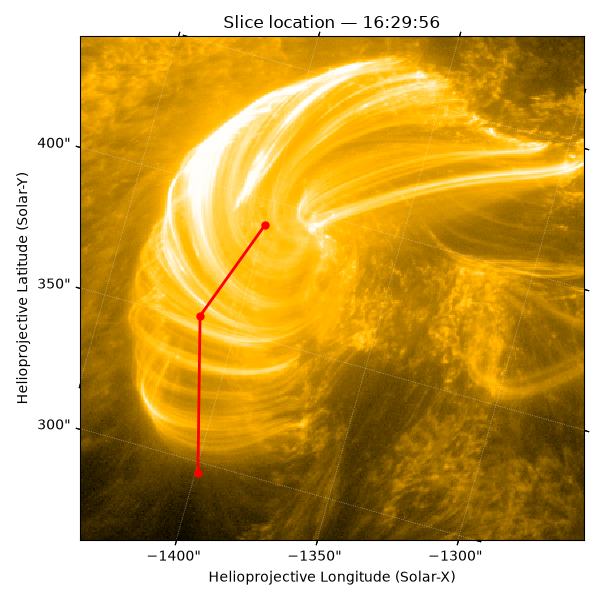

In [ ]:
import astropy.units as u
from astropy.coordinates import SkyCoord

#start and end points of the first slice
start = SkyCoord(
    -1399 * u.arcsec,
    296 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

end = SkyCoord(
    -1414 * u.arcsec,
    352 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

#new endpoint for the second segment
end2 = SkyCoord(
    -1400 * u.arcsec,
    391 * u.arcsec,
    frame=zoomed_map.coordinate_frame
)

fig = plt.figure(figsize=(6, 6))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)

zoomed_map.plot(axes=ax)

#first slice segment
ax.plot_coord(
    SkyCoord(
        [start.Tx, end.Tx],
        [start.Ty, end.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    color="red",
    linewidth=2
)

#second slice segment
ax.plot_coord(
    SkyCoord(
        [end.Tx, end2.Tx],
        [end.Ty, end2.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    color="red",
    linewidth=2
)

ax.plot_coord(
    SkyCoord(
        [start.Tx, end.Tx, end2.Tx],
        [start.Ty, end.Ty, end2.Ty],
        frame=zoomed_map.coordinate_frame
    ),
    marker="o",
    linestyle="none",
    color="red",
    markersize=5
)

ax.set_title(
    f"Slice location — {m.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_slice_location.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Data unit: DN / s
BUNIT: DN/s


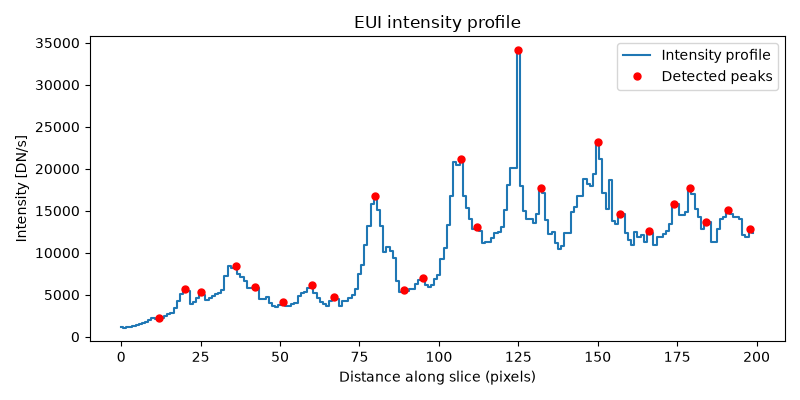

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#convert all three world coordinates to pixels


start_pixel = zoomed_map.world_to_pixel(start)
end_pixel = zoomed_map.world_to_pixel(end)
end2_pixel = zoomed_map.world_to_pixel(end2)

x1, y1 = start_pixel[0].value, start_pixel[1].value
x2, y2 = end_pixel[0].value, end_pixel[1].value
x3, y3 = end2_pixel[0].value, end2_pixel[1].value


#create pixels along the first segment

n_points_1 = int(np.hypot(x2 - x1, y2 - y1))

x_pixels_1 = np.linspace(x1, x2, n_points_1)
y_pixels_1 = np.linspace(y1, y2, n_points_1)


#create pixels along the second segment


n_points_2 = int(np.hypot(x3 - x2, y3 - y2))

x_pixels_2 = np.linspace(x2, x3, n_points_2)
y_pixels_2 = np.linspace(y2, y3, n_points_2)

#combine both segments
#remove the duplicate middle point

x_pixels = np.concatenate([
    x_pixels_1,
    x_pixels_2[1:]
])

y_pixels = np.concatenate([
    y_pixels_1,
    y_pixels_2[1:]
])


x_pixels = np.round(x_pixels).astype(int)
y_pixels = np.round(y_pixels).astype(int)


#make sure to stay inside the image


valid = (
    (x_pixels >= 0) &
    (x_pixels < zoomed_map.data.shape[1]) &
    (y_pixels >= 0) &
    (y_pixels < zoomed_map.data.shape[0])
)

x_pixels = x_pixels[valid]
y_pixels = y_pixels[valid]



#extract intensity along the complete path

intensity = zoomed_map.data[y_pixels, x_pixels]

print("Data unit:", m.unit)
print("BUNIT:", m.meta.get("BUNIT"))


#distance along the complete slice
distance = np.arange(len(intensity))


#detect peaks
from scipy.signal import find_peaks

peaks, properties = find_peaks(
    intensity,
    prominence=np.std(intensity) * 0.005,
    distance=2
)



plt.figure(figsize=(8, 4))

plt.plot(
    distance,
    intensity,
    drawstyle="steps-mid",
    label="Intensity profile"
)

plt.plot(
    distance[peaks],
    intensity[peaks],
    "ro",
    markersize=5,
    label="Detected peaks"
)

plt.xlabel("Distance along slice (pixels)")
plt.ylabel("Intensity [DN/s]")
plt.title("EUI intensity profile")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/eui_intensity_profile_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Number of peaks: 23
Peak 1: lon = -1400.63 arcsec, lat = 301.71 arcsec
Peak 2: lon = -1401.70 arcsec, lat = 305.50 arcsec
Peak 3: lon = -1402.37 arcsec, lat = 307.87 arcsec
Peak 4: lon = -1403.37 arcsec, lat = 313.21 arcsec
Peak 5: lon = -1404.30 arcsec, lat = 316.52 arcsec
Peak 6: lon = -1405.51 arcsec, lat = 320.78 arcsec
Peak 7: lon = -1406.71 arcsec, lat = 325.05 arcsec
Peak 8: lon = -1407.64 arcsec, lat = 328.36 arcsec
Peak 9: lon = -1409.38 arcsec, lat = 334.52 arcsec
Peak 10: lon = -1410.58 arcsec, lat = 338.78 arcsec
Peak 11: lon = -1411.39 arcsec, lat = 341.62 arcsec
Peak 12: lon = -1413.12 arcsec, lat = 347.77 arcsec
Peak 13: lon = -1413.32 arcsec, lat = 350.27 arcsec
Peak 14: lon = -1412.42 arcsec, lat = 356.15 arcsec
Peak 15: lon = -1411.33 arcsec, lat = 359.53 arcsec
Peak 16: lon = -1408.13 arcsec, lat = 368.10 arcsec
Peak 17: lon = -1407.03 arcsec, lat = 371.48 arcsec
Peak 18: lon = -1405.60 arcsec, lat = 375.46 arcsec
Peak 19: lon = -1404.17 arcsec, lat = 379.44 arcsec
P

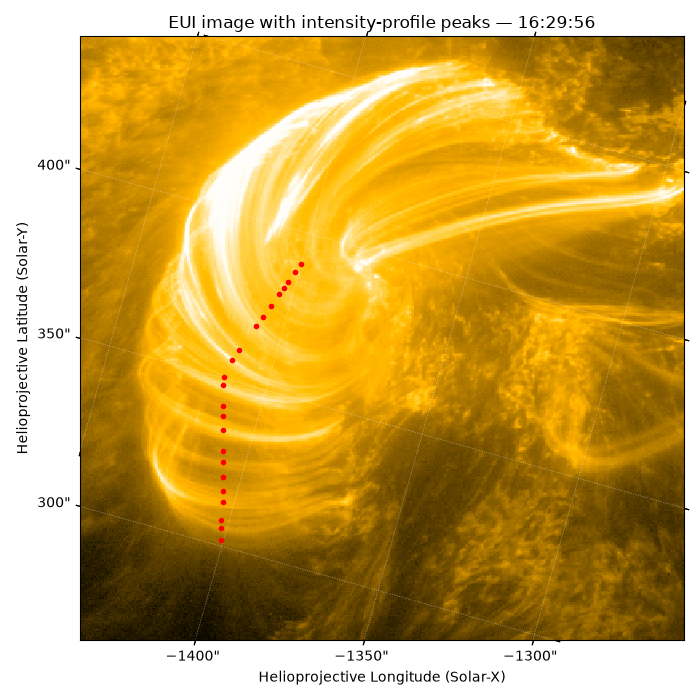

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import astropy.units as u
from astropy.coordinates import SkyCoord


peaks, properties = find_peaks(
    intensity,
    prominence=np.std(intensity) * 0.005,
    distance=2
)

print("Number of peaks:", len(peaks))


#get the pixel coordinates of each peak

peak_x_pixels = x_pixels[peaks]
peak_y_pixels = y_pixels[peaks]


peak_coords = zoomed_map.pixel_to_world(
    peak_x_pixels * u.pix,
    peak_y_pixels * u.pix
)


for i, coord in enumerate(peak_coords):
    print(
        f"Peak {i+1}: "
        f"lon = {coord.Tx.to(u.arcsec):.2f}, "
        f"lat = {coord.Ty.to(u.arcsec):.2f}"
    )



fig = plt.figure(figsize=(7, 7))

ax = fig.add_subplot(
    1, 1, 1,
    projection=zoomed_map.wcs
)

zoomed_map.plot(axes=ax)

ax.plot_coord(
    peak_coords,
    marker="o",
    linestyle="none",
    markersize=3,
    color="red"
)

ax.set_title(
    f"EUI image with intensity-profile peaks — {m.date.iso[11:19]}"
)

plt.tight_layout()

plt.savefig(
    "../figures/eui_slice_peaks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
for key, value in zoomed_map.meta.items():
    print(f"{key}: {value}")

simple: True
bitpix: 16
naxis: 2
naxis1: 378
naxis2: 378
longstrn: OGIP 1.0
comment: --------- General Description: -----------------------------------------
--------- Instrument and Observation Configuration: --------------------
--------- Description of Data Content: ---------------------------------
--------- Image Relative to Detector and Electronics: ------------------
--------- World Coordinate System Attitude: ----------------------------
--------- Front End Electronics: ---------------------------------------
--------- Temperature: -------------------------------------------------
--------- Telemetry Header: --------------------------------------------
--------- CEB Pixel Preprocessing: -------------------------------------
--------- Data Routing: ------------------------------------------------
--------- Onboard Processing: ------------------------------------------
--------- Derived Image Properties: ------------------------------------
--------- Solar Ephemeris: ------------

In [51]:
datamax = zoomed_map.meta["DATAMAX"]

max_slice = np.nanmax(intensity)

print("DATAMAX:", datamax)
print("Maximum slice intensity:", max_slice)
print("Fraction of DATAMAX:", max_slice / datamax)

DATAMAX: 42993.0390625
Maximum slice intensity: 34118.54
Fraction of DATAMAX: 0.79358286


So can see that it is not clipped or saturated.

Now going to try out the same slicing for different times:

In [53]:
import sunpy.map

start_time = pd.Timestamp("2026-08-20 16:14:00")
end_time = pd.Timestamp("2026-08-20 16:29:59")

available_frames = []

for file in files:
    m_temp = sunpy.map.Map(file)
    time = pd.Timestamp(m_temp.date.datetime)

    if start_time <= time <= end_time:
        available_frames.append((time, file))

print("Number of available frames:", len(available_frames))

print("\nAvailable frames:")
for time, file in available_frames:
    print(time, file)

Number of available frames: 16

Available frames:
2026-08-20 16:14:56.482000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161456482_V00.fits
2026-08-20 16:15:56.284000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161556284_V00.fits
2026-08-20 16:16:56.345000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161656345_V00.fits
2026-08-20 16:17:56.345000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161756345_V00.fits
2026-08-20 16:18:56.524000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161856524_V00.fits
2026-08-20 16:19:56.284000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T161956284_V00.fits
2026-08-20 16:20:56.297000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162056297_V00.fits
2026-08-20 16:21:56.284000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162156284_V00.fits
2026-08-20 16:22:56.285000 ../data/20260820T154500\solo_L2_eui-hrieuv174-image_20260820T162256

Going to pick 4 additional frames: 16:14, 16:18, 16:22, 16:26.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
import astropy.units as u
from astropy.coordinates import SkyCoord

selected_files = [
    "../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T161456482_V00.fits",
    "../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T161856524_V00.fits",
    "../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T162256285_V00.fits",
    "../data/20260820T154500/solo_L2_eui-hrieuv174-image_20260820T162656385_V00.fits",
]

profiles = []

for file in selected_files:

    m = sunpy.map.Map(file)

    zoom_width = 150 * u.arcsec
    zoom_height = 150 * u.arcsec

    bottom_left = SkyCoord(
        -1370 * u.arcsec - zoom_width / 2,
        375 * u.arcsec - zoom_height / 2,
        frame=m.coordinate_frame
    )

    top_right = SkyCoord(
        -1370 * u.arcsec + zoom_width / 2,
        375 * u.arcsec + zoom_height / 2,
        frame=m.coordinate_frame
    )

    zoomed_map = m.submap(
        bottom_left,
        top_right=top_right
    )

    start = SkyCoord(
        -1399 * u.arcsec,
        296 * u.arcsec,
        frame=zoomed_map.coordinate_frame
    )

    end = SkyCoord(
        -1414 * u.arcsec,
        352 * u.arcsec,
        frame=zoomed_map.coordinate_frame
    )

    end2 = SkyCoord(
        -1400 * u.arcsec,
        391 * u.arcsec,
        frame=zoomed_map.coordinate_frame
    )

    start_pixel = zoomed_map.world_to_pixel(start)
    end_pixel = zoomed_map.world_to_pixel(end)
    end2_pixel = zoomed_map.world_to_pixel(end2)

    x1, y1 = start_pixel[0].value, start_pixel[1].value
    x2, y2 = end_pixel[0].value, end_pixel[1].value
    x3, y3 = end2_pixel[0].value, end2_pixel[1].value

    n_points_1 = int(np.hypot(x2 - x1, y2 - y1))

    x_pixels_1 = np.linspace(x1, x2, n_points_1)
    y_pixels_1 = np.linspace(y1, y2, n_points_1)

    n_points_2 = int(np.hypot(x3 - x2, y3 - y2))

    x_pixels_2 = np.linspace(x2, x3, n_points_2)
    y_pixels_2 = np.linspace(y2, y3, n_points_2)


    x_pixels = np.concatenate([
        x_pixels_1,
        x_pixels_2[1:]
    ])

    y_pixels = np.concatenate([
        y_pixels_1,
        y_pixels_2[1:]
    ])


    x_pixels = np.round(x_pixels).astype(int)
    y_pixels = np.round(y_pixels).astype(int)


    valid = (
        (x_pixels >= 0) &
        (x_pixels < zoomed_map.data.shape[1]) &
        (y_pixels >= 0) &
        (y_pixels < zoomed_map.data.shape[0])
    )

    x_pixels = x_pixels[valid]
    y_pixels = y_pixels[valid]


    intensity = zoomed_map.data[y_pixels, x_pixels]

    distance = np.arange(len(intensity))

   
    peaks, properties = find_peaks(
        intensity,
        prominence=np.std(intensity) * 0.005,
        distance=2
    )

    profiles.append({
        "time": m.date.datetime,
        "map": zoomed_map,
        "distance": distance,
        "intensity": intensity,
        "peaks": peaks,
        "x_pixels": x_pixels,
        "y_pixels": y_pixels
    })

    print(
        f"{m.date.iso[11:19]}  |  "
        f"{len(intensity)} pixels  |  "
        f"{len(peaks)} peaks"
    )

16:14:56  |  200 pixels  |  31 peaks
16:18:56  |  200 pixels  |  35 peaks
16:22:56  |  200 pixels  |  37 peaks
16:26:56  |  200 pixels  |  38 peaks


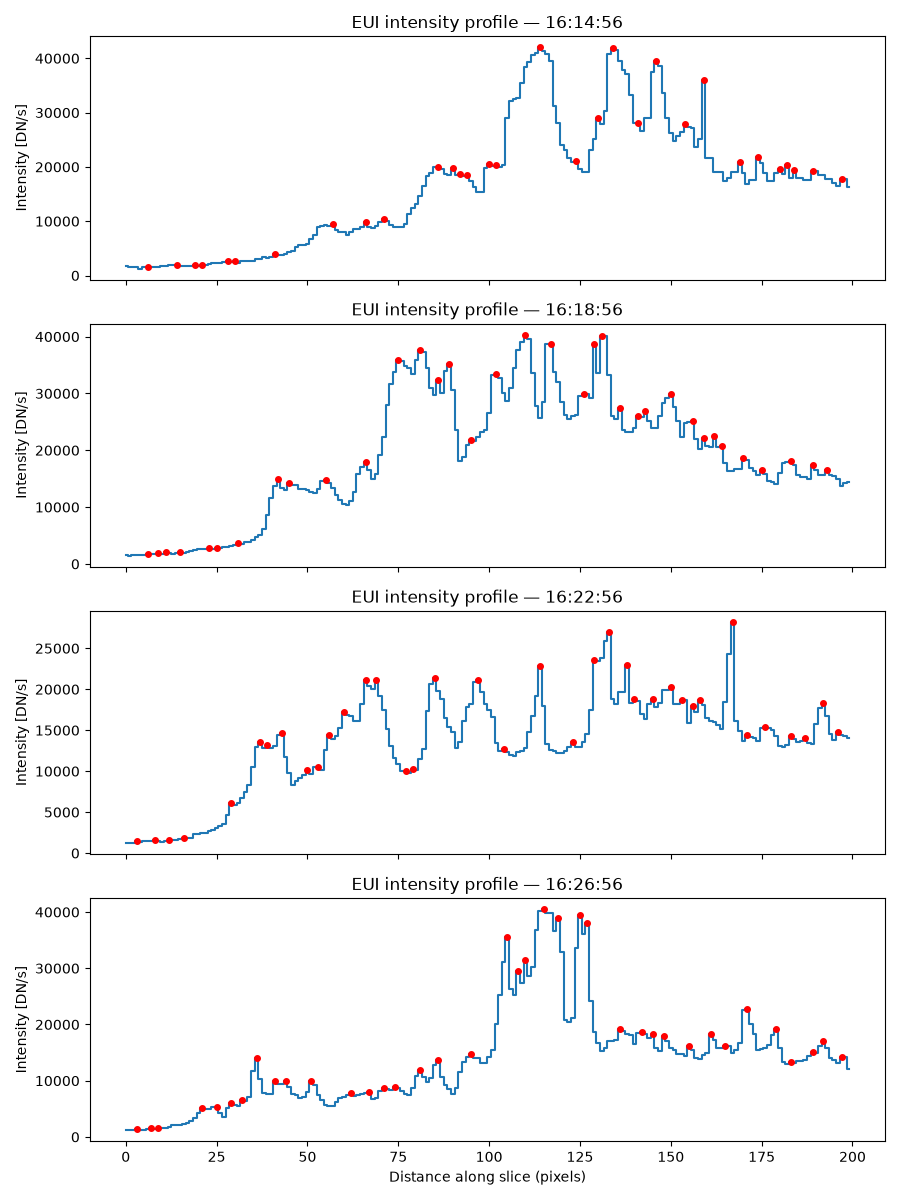

In [ ]:
#satisfying to see that number of peaks goes up as time passes (and the loop becomes more evident)

fig, axes = plt.subplots(
    4, 1,
    figsize=(9, 12),
    sharex=True
)

for ax, profile in zip(axes, profiles):

    ax.plot(
        profile["distance"],
        profile["intensity"],
        drawstyle="steps-mid"
    )

    ax.plot(
        profile["distance"][profile["peaks"]],
        profile["intensity"][profile["peaks"]],
        "ro",
        markersize=4
    )

    ax.set_ylabel("Intensity [DN/s]")

    ax.set_title(
        f"EUI intensity profile — "
        f"{profile['time'].strftime('%H:%M:%S')}"
    )

axes[-1].set_xlabel("Distance along slice (pixels)")

plt.tight_layout()

plt.savefig(
    "../figures/eui_slice_profiles_4stages.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

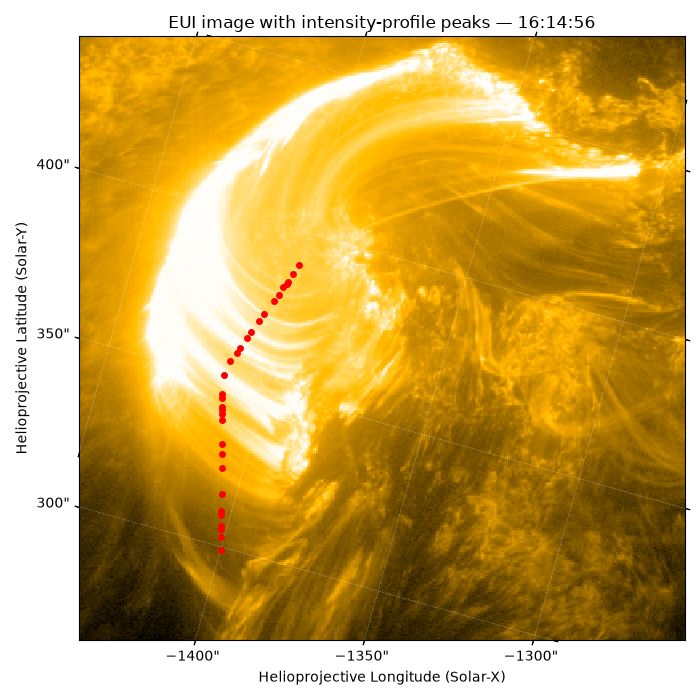

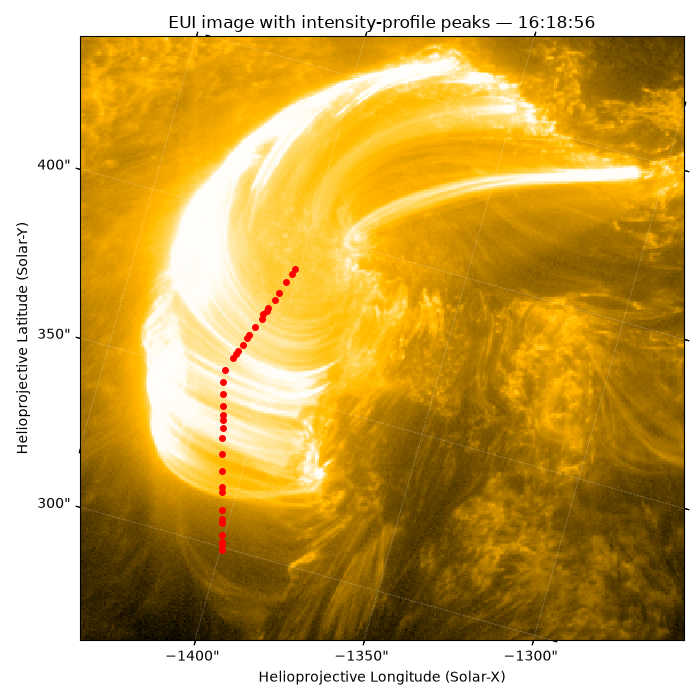

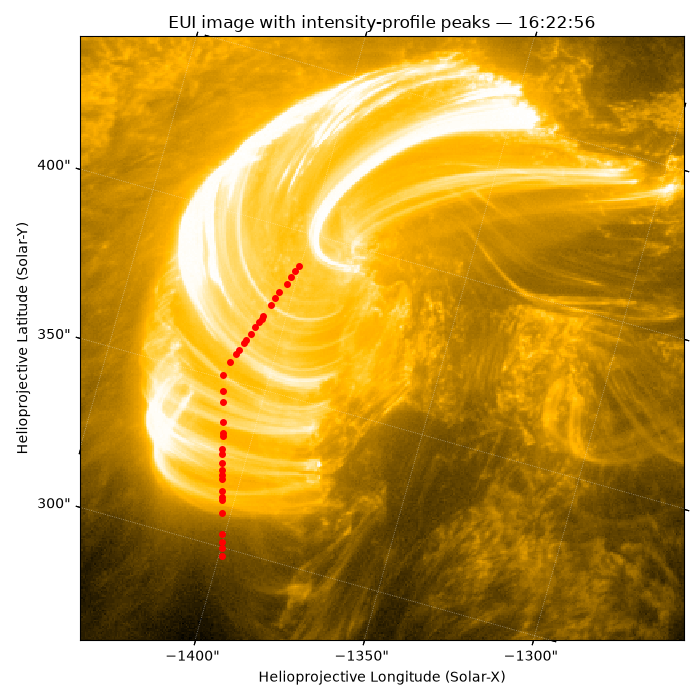

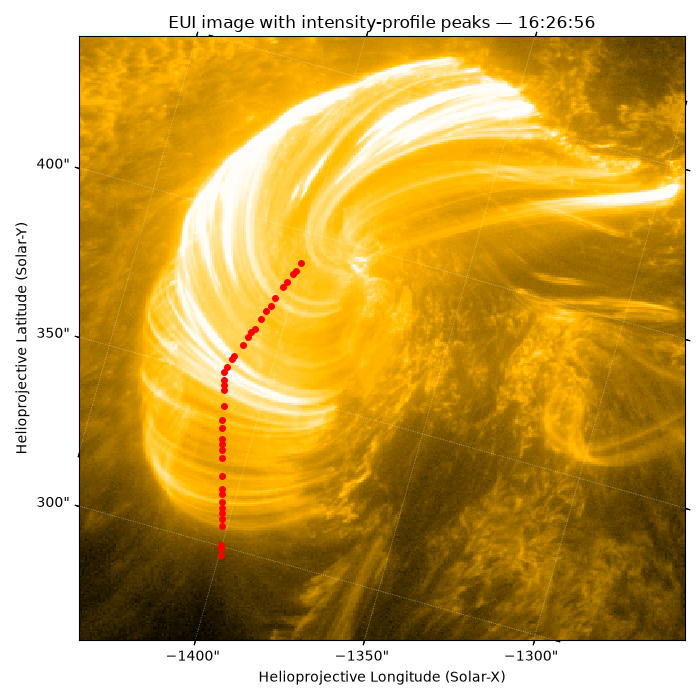

In [ ]:
for i, profile in enumerate(profiles):

    zoomed_map = profile["map"]

    
    peak_x_pixels = profile["x_pixels"][profile["peaks"]]
    peak_y_pixels = profile["y_pixels"][profile["peaks"]]

    
    peak_coords = zoomed_map.pixel_to_world(
        peak_x_pixels * u.pix,
        peak_y_pixels * u.pix
    )

    fig = plt.figure(figsize=(7, 7))

    ax = fig.add_subplot(
        1, 1, 1,
        projection=zoomed_map.wcs
    )

    zoomed_map.plot(axes=ax)

    ax.plot_coord(
        peak_coords,
        marker="o",
        linestyle="none",
        markersize=4,
        color="red"
    )

    ax.set_title(
        f"EUI image with intensity-profile peaks — "
        f"{profile['time'].strftime('%H:%M:%S')}"
    )

    plt.tight_layout()

    plt.savefig(
        f"../figures/eui_slice_peaks_stage{i+1}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()